# 03 — A3: BiLSTM with attention (rounds R1 and R2)

**Owner:** M2 · **Plan:** Phases 5–6 · **Split:** frozen 70/15/15 (hash `b74d294f…`). Models are selected on **validation**. The test split is not touched until R3.

**Model.** Log-mel frames (151 × 64, centred 1.5 s window) → 2-layer bidirectional LSTM (128 units per direction) → additive attention pooling over time → linear layer over the 12 words (`src/models/bilstm.py`). The recurrence reads the frames **in order**, so like the HMM (A2) it should separate words that share sounds but order them differently (*tisa*/*sita*). Unlike the HMM, it learns its own features and is trained discriminatively.

**The bar to beat** (validation, `notebooks/02_baselines.ipynb`): A1 77.9% / log loss 0.725 (order-free); A2 95.2% / log loss 0.180 (order-aware HMM).

**Rounds.**
- R1 trains the default configuration.
- R2 runs a greedy, one-factor-at-a-time search: each run changes one thing relative to the current best configuration and keeps the change only if validation log loss improves.

Every model is temperature-scaled (cross-fitted on val), as for A1/A2.

**Compute.** A GPU is strongly recommended. One epoch takes about 1–2 s on a Kaggle T4, against about 33 s on an 8-thread CPU. `RERUN = False` reuses logged runs, so re-executing takes seconds anywhere. The runs in this notebook were trained on a Kaggle **Tesla T4** (recorded per run in `results/runs/`). A later re-execution that reuses them prints the device of *that* session, not the training device.

In [1]:
import glob, os, shutil, sys, subprocess

REPO_URL = "https://github.com/Hassan-Adelani-Luqman/nlp-sequential-modeling-group21.git"
REPO_DIR = "nlp-sequential-modeling-group21"
if os.path.isdir("/kaggle/input") or "google.colab" in sys.modules:
    # A code-snapshot dataset attached on Kaggle takes precedence over GitHub (lets you run code before it is pushed).
    snapshot = glob.glob("/kaggle/input/**/src/train_torch.py", recursive=True) if os.path.isdir("/kaggle/input") else []
    zipped = glob.glob("/kaggle/input/**/group21-code*.zip", recursive=True) if os.path.isdir("/kaggle/input") else []
    if not snapshot and zipped:  # the archive was not unpacked on upload: unpack it ourselves
        import zipfile
        zipfile.ZipFile(zipped[0]).extractall("/tmp/snapshot")
        snapshot = glob.glob("/tmp/snapshot/**/src/train_torch.py", recursive=True)
    if snapshot:
        REPO_DIR = "/tmp/" + REPO_DIR   # outside /kaggle/working, so only results are saved as outputs
        if not os.path.isdir(REPO_DIR):
            shutil.copytree(os.path.dirname(os.path.dirname(snapshot[0])), REPO_DIR)
        print("using code snapshot:", os.path.dirname(os.path.dirname(snapshot[0])))
    elif not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
import copy, json, platform
import numpy as np, pandas as pd, torch, yaml
import matplotlib.pyplot as plt
from IPython.display import display

from src.augment import LogMelAugment
from src.data import label_names, load_splits
from src.evaluate import (KEY_PAIRS, compute_metrics, cross_fitted_temperature, load_predictions, pair_confusion,
                          plot_confusion_matrix, plot_learning_curves)
from src.experiment import ExperimentRunner
from src.features import PRESETS, cached_features
from src.models.bilstm import BiLSTMAttention, count_parameters
from src.paths import CONFIGS_DIR, REPO_ROOT, checkpoints_dir, results_dir
from src.plotting import MODEL_COLORS, SERIES, apply_style, progression_chart, save_figure
from src.train_torch import TrainConfig, train_model
from src.utils import build_experiment_table, get_device, gpu_name, set_seed

RERUN = False   # True = retrain every run and overwrite its log; False = reuse runs that are already logged
SEED, MEMBER = 42, "M2"
SMOKE = os.environ.get("SWN_SMOKE") == "1"   # tiny end-to-end check (use with SWN_OUTPUT_DIR)
set_seed(SEED)
apply_style()
torch.set_num_threads(os.cpu_count() or 4)

NAMES = label_names()
splits = load_splits()
train, val = splits["train"], splits["val"]
if SMOKE:
    take = lambda df, n: df.groupby("label_id", group_keys=False).head(n).reset_index(drop=True)
    train, val = take(train, 12), take(val, 6)
y_tr, y_val = train.label_id.to_numpy(), val.label_id.to_numpy()
DEVICE = get_device()
NUM_WORKERS = 2 if (os.path.isdir("/kaggle/input") or "google.colab" in sys.modules) else 0
runner = ExperimentRunner(val, NAMES, member=MEMBER, notebook="notebooks/03_bilstm.ipynb", seed=SEED, rerun=RERUN)
print(f"train {len(train)} · val {len(val)} · device {gpu_name()} · "
      f"Python {platform.python_version()} · torch {torch.__version__}")

train 2940 · val 630 · device cpu · Python 3.14.3 · torch 2.14.0+cpu


In [3]:
def augmenter(kind, feature):
    '''Augmentation policy by name. Noise injection assumes log-mel dB, so it is dropped for MFCC inputs.'''
    if kind == "none":
        return None
    if kind == "specaugment":
        return LogMelAugment.specaugment_only(seed=SEED)
    if kind == "full":
        return LogMelAugment(seed=SEED, noise_snr_db=(10.0, 30.0) if feature == "logmel" else None)
    raise ValueError(kind)


def a3_fit_predict(exp_id, cfg):
    '''Train one configuration; return temperature-scaled val probabilities and run details.'''
    def fit_predict():
        feat = cfg["features"]
        X_tr, X_va = cached_features(train, **feat), cached_features(val, **feat)
        train_cfg = TrainConfig(**{**cfg["train"], "seed": SEED, "num_workers": NUM_WORKERS,
                                   **({"epochs": 2} if SMOKE else {})})
        result = train_model(lambda: BiLSTMAttention(n_features=X_tr.shape[-1], **cfg["model"]),
                             X_tr, y_tr, X_va, y_val, train_cfg, augment=augmenter(cfg["augment"], feat["feature"]),
                             device=DEVICE, checkpoint=checkpoints_dir() / f"{exp_id}_seed{SEED}.pt")
        probs, temperature = cross_fitted_temperature(result.val_logits, y_val, seed=SEED)
        return probs, {"best_epoch": result.best_epoch, "epochs_run": int(len(result.history)),
                       "temperature": temperature, "n_params": count_parameters(result.model),
                       "history": result.history}
    return fit_predict


DEFAULT = {
    "features": dict(PRESETS["logmel"]),                                  # (151, 64) log-mel, centred 1.5 s window
    "model": {"hidden": 128, "layers": 2, "dropout": 0.3, "bidirectional": True,
              "pooling": "attention", "conv_frontend": False},
    "train": {"epochs": 40, "batch_size": 64, "lr": 1e-3, "patience": 5},
    "augment": "none",
}

## R1 — default configuration

A3-R1-01 [reused] log loss 0.214 · acc 94.6% · macro-F1 0.946 · ECE 0.023 · tisa/sita 0.0% · 0.4 min


best epoch 19 of 24 · 630,028 parameters · temperature 0.72


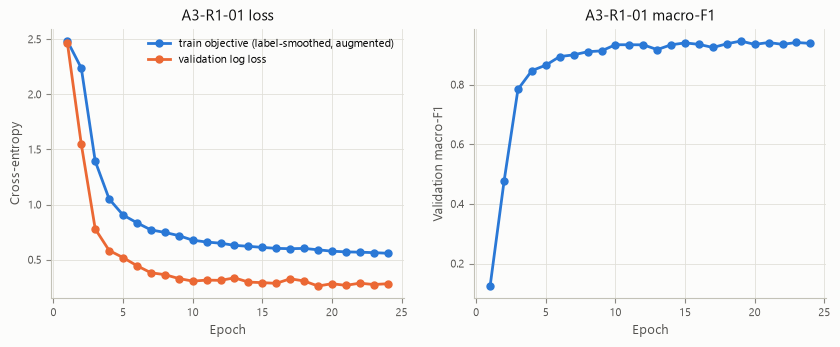

In [4]:
r1 = runner.run("A3-R1-01", "first A3 run: 2-layer BiLSTM (128/direction) + attention, log-mel 64, no augmentation",
                "default configuration from Plan.md Phase 5", a3_fit_predict("A3-R1-01", DEFAULT), copy.deepcopy(DEFAULT))
print(f"best epoch {r1['extra']['best_epoch']} of {r1['extra']['epochs_run']} · "
      f"{r1['extra']['n_params']:,} parameters · temperature {r1['extra']['temperature']:.2f}")
axes = plot_learning_curves(r1["extra"]["history"], title="A3-R1-01")
save_figure(axes[0].figure, "a3_r1_learning_curves")
plt.show()

**Observations → next step (R1)**
- **The default model already matches the classical best.** It reaches 94.6% val accuracy and log loss 0.214 with no augmentation (A2: 95.2%, 0.180).
- **It learns the order-dependent pairs without any hand-built temporal structure.** It confuses *tisa/sita* on 0% of their clips and *nne/nane* on 1.0%.
- **It over-fits mildly.** Validation loss (before temperature scaling) is lowest at epoch 19 (0.261) and rises to 0.282 by epoch 24, while the training loss keeps falling (0.590 → 0.559).
- **→ Next:** with only ~245 training clips per word, augmentation is the first R2 factor.

## R2 — greedy one-factor-at-a-time search
Each step changes one factor of the **current best** configuration. The change is kept only if validation log loss (after temperature scaling) improves. The factors, and the question each one asks:

| Run | Change | Question |
|---|---|---|
| 01 | SpecAugment | Does masking regularise a model trained on only ~245 clips per word? |
| 02 | Full augmentation (+ shift, tempo, noise) | Does simulating speaker and recording variation help further? |
| 03 | Last-state pooling | Does attention pooling beat the final hidden state? |
| 04 | Mean pooling | ... or plain averaging over time? |
| 05 | Unidirectional LSTM | How much does future context help? (A unidirectional model can stream.) |
| 06 | MFCC-40 + Δ + ΔΔ input | Is the less-compressed log-mel better for a learned model? |
| 07 / 08 | 1.0 s / 2.0 s window | How much temporal context is needed? |
| 09 | Silence trim instead of the energy window | Which way of locating the word works better for A3? |
| 10 / 11 | Learning rate 5e-4 / 2e-3 | Sensitivity to the learning rate |
| 12 | Conv1d front-end | Does de Andrade et al.'s convolutional-recurrent design (convolution before the LSTM) help? |

In [5]:
best_cfg, best_run = copy.deepcopy(DEFAULT), r1
decisions = []


def try_change(exp_id, change, rationale, **overrides):
    '''Run the current best configuration with one change; keep the change if val log loss improves.'''
    global best_cfg, best_run
    cfg = copy.deepcopy(best_cfg)
    for section, values in overrides.items():
        cfg[section] = values if not isinstance(values, dict) else {**cfg[section], **values}
    r = runner.run(exp_id, change, rationale, a3_fit_predict(exp_id, cfg), cfg)
    kept = r["metrics"]["log_loss"] < best_run["metrics"]["log_loss"]
    decisions.append({"exp_id": exp_id, "change": change, "val_logloss": r["metrics"]["log_loss"],
                      "best_before": best_run["metrics"]["log_loss"], "kept": kept})
    if kept:
        best_cfg, best_run = cfg, r
    print(f"   → {'KEPT' if kept else 'rejected'} (current best: {best_run['exp_id']}, "
          f"log loss {best_run['metrics']['log_loss']:.3f})")
    return r


try_change("A3-R2-01", "+ SpecAugment (2 time masks <= 20 frames, 2 frequency masks <= 8 bands)",
           "only ~245 clips per word: masking should reduce over-fitting", augment="specaugment")
try_change("A3-R2-02", "full augmentation: SpecAugment + time shift + tempo 0.9-1.1x + noise at 10-30 dB SNR",
           "simulate speaker-rate and recording variation (synthetic only: no external data allowed)", augment="full")

A3-R2-01 [reused] log loss 0.153 · acc 96.0% · macro-F1 0.960 · ECE 0.026 · tisa/sita 1.0% · 0.5 min


   → KEPT (current best: A3-R2-01, log loss 0.153)
A3-R2-02 [reused] log loss 0.166 · acc 95.9% · macro-F1 0.959 · ECE 0.016 · tisa/sita 0.0% · 0.9 min


   → rejected (current best: A3-R2-01, log loss 0.153)


{'metrics': {'macro_f1': 0.9587451018210377,
  'weighted_f1': 0.9587677787612602,
  'accuracy': 0.9587301587301588,
  'log_loss': 0.16641559943797612,
  'roc_auc_ovr': 0.9974929964689031,
  'ece': 0.015528544064037352,
  'per_class': {'hapana': {'precision': 0.8947368421052632,
    'recall': 0.9622641509433962,
    'f1': 0.9272727272727272,
    'support': 53},
   'kumi': {'precision': 0.9122807017543859,
    'recall': 1.0,
    'f1': 0.9541284403669725,
    'support': 52},
   'mbili': {'precision': 1.0,
    'recall': 0.9622641509433962,
    'f1': 0.9807692307692307,
    'support': 53},
   'moja': {'precision': 0.9607843137254902,
    'recall': 0.9423076923076923,
    'f1': 0.9514563106796117,
    'support': 52},
   'nane': {'precision': 0.9622641509433962,
    'recall': 0.9807692307692307,
    'f1': 0.9714285714285714,
    'support': 52},
   'ndio': {'precision': 0.9444444444444444,
    'recall': 0.9622641509433962,
    'f1': 0.9532710280373832,
    'support': 53},
   'nne': {'precision

In [6]:
try_change("A3-R2-03", "last hidden state instead of attention pooling",
           "does learned attention over frames beat the recurrence's final state?", model={"pooling": "last"})
try_change("A3-R2-04", "mean pooling instead of attention pooling",
           "does learned attention beat uniform averaging over time?", model={"pooling": "mean"})
try_change("A3-R2-05", "unidirectional LSTM (forward only)",
           "how much does future context help? A unidirectional model could run while the word is spoken",
           model={"bidirectional": False})

A3-R2-03 [reused] log loss 0.915 · acc 69.7% · macro-F1 0.689 · ECE 0.065 · tisa/sita 8.6% · 0.5 min


   → rejected (current best: A3-R2-01, log loss 0.153)
A3-R2-04 [reused] log loss 0.235 · acc 93.8% · macro-F1 0.938 · ECE 0.023 · tisa/sita 0.0% · 0.4 min


   → rejected (current best: A3-R2-01, log loss 0.153)
A3-R2-05 [reused] log loss 0.246 · acc 93.7% · macro-F1 0.937 · ECE 0.022 · tisa/sita 1.0% · 0.4 min


   → rejected (current best: A3-R2-01, log loss 0.153)


{'metrics': {'macro_f1': 0.9367933572392951,
  'weighted_f1': 0.9366673215291282,
  'accuracy': 0.9365079365079365,
  'log_loss': 0.24627741460589903,
  'roc_auc_ovr': 0.9964724767490614,
  'ece': 0.021527115453842206,
  'per_class': {'hapana': {'precision': 0.9259259259259259,
    'recall': 0.9433962264150944,
    'f1': 0.9345794392523364,
    'support': 53},
   'kumi': {'precision': 0.9622641509433962,
    'recall': 0.9807692307692307,
    'f1': 0.9714285714285714,
    'support': 52},
   'mbili': {'precision': 0.9230769230769231,
    'recall': 0.9056603773584906,
    'f1': 0.9142857142857143,
    'support': 53},
   'moja': {'precision': 0.98,
    'recall': 0.9423076923076923,
    'f1': 0.9607843137254902,
    'support': 52},
   'nane': {'precision': 0.8909090909090909,
    'recall': 0.9423076923076923,
    'f1': 0.9158878504672897,
    'support': 52},
   'ndio': {'precision': 0.9423076923076923,
    'recall': 0.9245283018867925,
    'f1': 0.9333333333333333,
    'support': 53},
   'n

In [7]:
MFCC40 = {"feature": "mfcc", "crop": "energy", "seconds": 1.5, "n_mfcc": 40}
try_change("A3-R2-06", "MFCC-40 + delta + delta-delta (120-d) instead of log-mel 64",
           "the DCT in MFCCs decorrelates for GMMs; a learned model may prefer the less-compressed log-mel",
           features=MFCC40)
try_change("A3-R2-07", "1.0 s window instead of 1.5 s", "less silence around the word, but long words may be cut",
           features={"seconds": 1.0})
try_change("A3-R2-08", "2.0 s window instead of 1.5 s", "more context for long words (hapana), more silence for short ones",
           features={"seconds": 2.0})
try_change("A3-R2-09", "silence trim (top_db 30) + fixed length instead of the energy window",
           "the other way of locating the word; it left noisy tails for the HMM",
           features={"crop": "trim"})

A3-R2-06 [reused] log loss 0.147 · acc 96.3% · macro-F1 0.964 · ECE 0.018 · tisa/sita 0.0% · 1.3 min


   → KEPT (current best: A3-R2-06, log loss 0.147)


A3-R2-07 [reused] log loss 0.144 · acc 96.3% · macro-F1 0.964 · ECE 0.017 · tisa/sita 1.0% · 0.6 min


   → KEPT (current best: A3-R2-07, log loss 0.144)
A3-R2-08 [reused] log loss 0.148 · acc 96.8% · macro-F1 0.968 · ECE 0.017 · tisa/sita 0.0% · 0.8 min


   → rejected (current best: A3-R2-07, log loss 0.144)


A3-R2-09 [reused] log loss 0.759 · acc 75.9% · macro-F1 0.760 · ECE 0.059 · tisa/sita 6.7% · 0.5 min


   → rejected (current best: A3-R2-07, log loss 0.144)


{'metrics': {'macro_f1': 0.7600854076998348,
  'weighted_f1': 0.7599468355943028,
  'accuracy': 0.7587301587301587,
  'log_loss': 0.7587877646735989,
  'roc_auc_ovr': 0.9672766321269094,
  'ece': 0.059361770480466626,
  'per_class': {'hapana': {'precision': 0.7358490566037735,
    'recall': 0.7358490566037735,
    'f1': 0.7358490566037735,
    'support': 53},
   'kumi': {'precision': 0.8163265306122449,
    'recall': 0.7692307692307693,
    'f1': 0.7920792079207921,
    'support': 52},
   'mbili': {'precision': 0.6885245901639344,
    'recall': 0.7924528301886793,
    'f1': 0.7368421052631579,
    'support': 53},
   'moja': {'precision': 0.9166666666666666,
    'recall': 0.8461538461538461,
    'f1': 0.88,
    'support': 52},
   'nane': {'precision': 0.8297872340425532,
    'recall': 0.75,
    'f1': 0.7878787878787878,
    'support': 52},
   'ndio': {'precision': 0.76,
    'recall': 0.7169811320754716,
    'f1': 0.7378640776699029,
    'support': 53},
   'nne': {'precision': 0.68421052

In [8]:
try_change("A3-R2-10", "peak learning rate 5e-4 instead of 1e-3", "learning-rate sensitivity (lower)", train={"lr": 5e-4})
try_change("A3-R2-11", "peak learning rate 2e-3 instead of 1e-3", "learning-rate sensitivity (higher)", train={"lr": 2e-3})
try_change("A3-R2-12", "Conv1d front-end (2 x Conv1d k=5, 128 ch) before the LSTM",
           "local spectral-temporal features before the recurrence", model={"conv_frontend": True})
A3_BEST = best_run
print("→ best A3 run:", A3_BEST["exp_id"])
display(pd.DataFrame(decisions).style.format({"val_logloss": "{:.3f}", "best_before": "{:.3f}"}).hide(axis="index"))

A3-R2-10 [reused] log loss 0.145 · acc 96.2% · macro-F1 0.962 · ECE 0.021 · tisa/sita 1.0% · 0.4 min


   → rejected (current best: A3-R2-07, log loss 0.144)


A3-R2-11 [reused] log loss 0.142 · acc 97.0% · macro-F1 0.970 · ECE 0.020 · tisa/sita 0.0% · 0.4 min


   → KEPT (current best: A3-R2-11, log loss 0.142)


A3-R2-12 [reused] log loss 0.134 · acc 97.0% · macro-F1 0.970 · ECE 0.016 · tisa/sita 0.0% · 0.5 min


   → KEPT (current best: A3-R2-12, log loss 0.134)
→ best A3 run: A3-R2-12


exp_id,change,val_logloss,best_before,kept
A3-R2-01,"+ SpecAugment (2 time masks <= 20 frames, 2 frequency masks <= 8 bands)",0.153,0.214,True
A3-R2-02,full augmentation: SpecAugment + time shift + tempo 0.9-1.1x + noise at 10-30 dB SNR,0.166,0.153,False
A3-R2-03,last hidden state instead of attention pooling,0.915,0.153,False
A3-R2-04,mean pooling instead of attention pooling,0.235,0.153,False
A3-R2-05,unidirectional LSTM (forward only),0.246,0.153,False
A3-R2-06,MFCC-40 + delta + delta-delta (120-d) instead of log-mel 64,0.147,0.153,True
A3-R2-07,1.0 s window instead of 1.5 s,0.144,0.147,True
A3-R2-08,2.0 s window instead of 1.5 s,0.148,0.144,False
A3-R2-09,silence trim (top_db 30) + fixed length instead of the energy window,0.759,0.144,False
A3-R2-10,peak learning rate 5e-4 instead of 1e-3,0.145,0.144,False


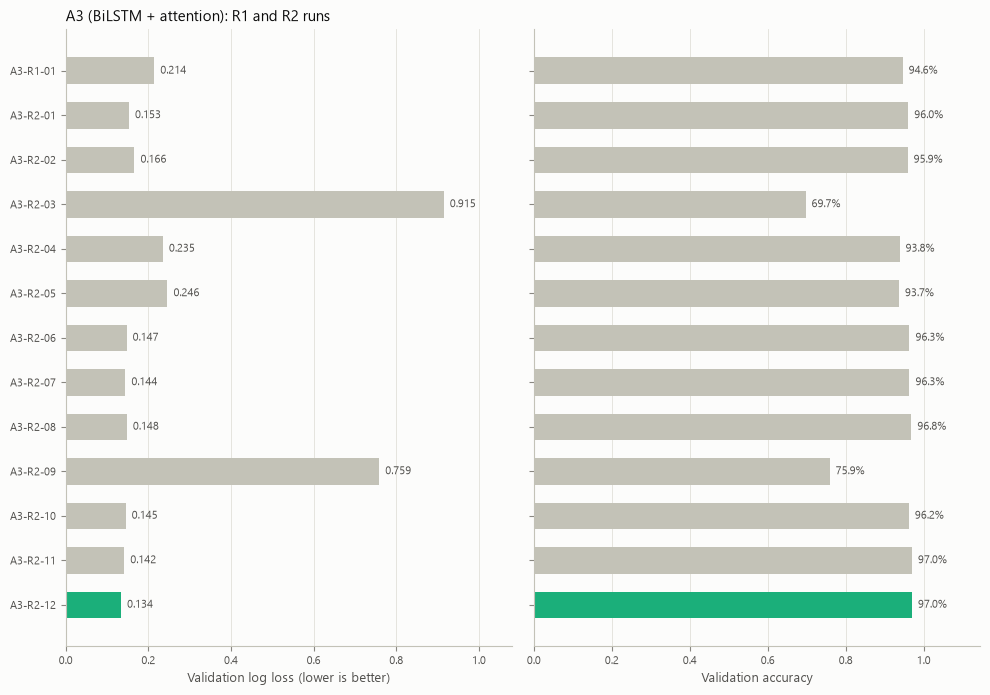

,change,val_logloss,val_acc,val_macro_f1,ece,tisa/sita,nne/nane,minutes
exp_id,,,,,,,,
A3-R1-01,"first A3 run: 2-layer BiLSTM (128/direction) + attention, log-mel 64, no augmentation",0.214,94.6%,0.946,0.023,0.0%,1.0%,0.4
A3-R2-01,"+ SpecAugment (2 time masks <= 20 frames, 2 frequency masks <= 8 bands)",0.153,96.0%,0.960,0.026,1.0%,0.0%,0.5
A3-R2-02,full augmentation: SpecAugment + time shift + tempo 0.9-1.1x + noise at 10-30 dB SNR,0.166,95.9%,0.959,0.016,0.0%,0.0%,0.9
A3-R2-03,last hidden state instead of attention pooling,0.915,69.7%,0.689,0.065,8.6%,7.7%,0.5
A3-R2-04,mean pooling instead of attention pooling,0.235,93.8%,0.938,0.023,0.0%,0.0%,0.4
A3-R2-05,unidirectional LSTM (forward only),0.246,93.7%,0.937,0.022,1.0%,1.0%,0.4
A3-R2-06,MFCC-40 + delta + delta-delta (120-d) instead of log-mel 64,0.147,96.3%,0.964,0.018,0.0%,0.0%,1.3
A3-R2-07,1.0 s window instead of 1.5 s,0.144,96.3%,0.964,0.017,1.0%,0.0%,0.6
A3-R2-08,2.0 s window instead of 1.5 s,0.148,96.8%,0.968,0.017,0.0%,0.0%,0.8


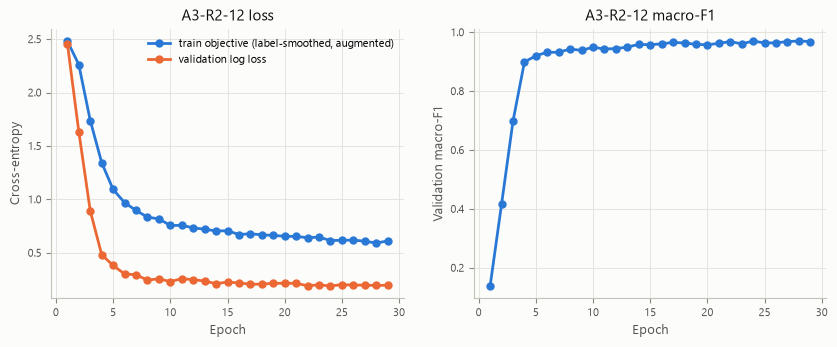

In [9]:
fig = progression_chart(runner.summary("A3"), A3_BEST["exp_id"], MODEL_COLORS["A3"], "A3 (BiLSTM + attention): R1 and R2 runs",
                        "a3_r2_progression")
plt.show()
display(ExperimentRunner.styled(runner.summary("A3")))
axes = plot_learning_curves(A3_BEST["extra"]["history"], title=A3_BEST["exp_id"])
save_figure(axes[0].figure, "a3_best_learning_curves")
plt.show()

**Observations → decision (R2)**
- **Augmentation.** SpecAugment was the largest single gain: log loss 0.214 → 0.153, accuracy 94.6% → 96.0%. It also delayed over-fitting: the best epoch moved from 19 to 32, and validation loss barely rose afterwards. Adding time shift, tempo and noise did not help further (0.166), so masking regularised better than our synthetic recording variation, which may not match the real variation in the clips.
- **Pooling matters enormously.** Last-state pooling collapsed to 69.7% (log loss 0.915). It stayed near chance for about 15 epochs and was still improving at the 40-epoch limit. Mean pooling (93.8%) was also worse than attention (96.0%).
  - A likely reason: the word sits in the middle of the window, with tens of frames of silence on each side. The final state of each direction is only reached after that silence, so the evidence must survive it. Attention reads the word's frames directly.
- **Direction.** A forward-only LSTM lost 2.3 points (93.7%; log loss 0.246 vs 0.153), so future context matters. This fits EDA 8, where the second syllable separates the *ta-* words. A streaming, forward-only deployment would pay this price.
- **Input.**
  - MFCC-40 + Δ + ΔΔ slightly beat log-mel (log loss 0.147 vs 0.153).
  - A tighter 1.0 s window slightly beat 1.5 s (0.144).
  - A 2.0 s window gave the highest accuracy (96.8%) but slightly worse log loss (0.148), so the rule rejected it.
  - These differences are at most 0.01 in log loss, only a few clips, and within what a different seed could produce. R3's three seeds will show the spread.
- **Locating the word.** Silence trimming failed badly for A3 too (75.9%, log loss 0.759), as it did for the HMM. Trimmed clips keep noisy tails, so the centred fixed-length crop of a long trimmed clip can miss the word.
- **Learning rate.** A peak of 2e-3 was marginally better than 1e-3 (0.142 vs 0.144), and 5e-4 no better. The model is insensitive in this range.
- **Convolutional front-end.** Kept: log loss 0.142 → 0.134, with accuracy unchanged at 97.0%. The final A3 is therefore a convolutional-recurrent network, like de Andrade et al.'s.
  - The gain is small and changes no predictions' correctness, so the recurrent core does most of the work.
  - For a clean recurrent-vs-convolutional comparison with A4, use **A3-R2-11** as the purely recurrent reference point (97.0%, log loss 0.142).
- **→ Final A3: A3-R2-12.** MFCC-40 + Δ + ΔΔ, centred 1.0 s window, SpecAugment, peak learning rate 2e-3, Conv1d front-end + 2-layer BiLSTM + attention. Validation: 97.0% accuracy, log loss 0.134, ECE 0.016.

## A3 against the classical baselines
All three models are scored on the same 630 validation clips, using the logged predictions of the final A1 (A1-R0-03) and A2 (A2-R2-03).

,run,val log loss,val accuracy,val macro-F1,ECE,tisa/sita,nne/nane,tatu/tano,saba/sita
A1,A1-R0-03,0.725027,0.779365,0.778867,0.035461,0.066667,0.057692,0.084906,0.0
A2,A2-R2-03,0.179942,0.952381,0.952676,0.025088,0.0,0.009615,0.018868,0.009524
A3,A3-R2-12,0.133987,0.969841,0.969908,0.01626,0.0,0.0,0.0,0.009524


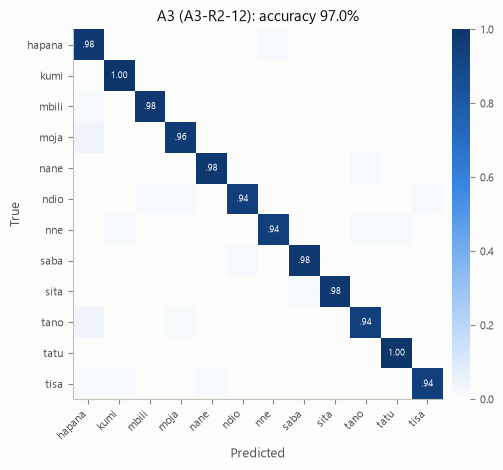

In [10]:
others = {}
for name, exp_id in (("A1", "A1-R0-03"), ("A2", "A2-R2-03")):
    candidates = [base / "predictions" / f"{exp_id}_seed{SEED}_val.csv" for base in (results_dir(), REPO_ROOT / "results")]
    path = next((c for c in candidates if c.exists()), candidates[0])
    if path.exists() and not SMOKE:
        df, probs = load_predictions(path)
        assert (df["id"].to_numpy() == val["id"].to_numpy()).all()
        others[name] = {"exp_id": exp_id, "probs": probs, "metrics": compute_metrics(y_val, probs, NAMES)}
models = {**others, "A3": A3_BEST}
comparison = pd.DataFrame({
    name: {"run": r["exp_id"], "val log loss": r["metrics"]["log_loss"], "val accuracy": r["metrics"]["accuracy"],
           "val macro-F1": r["metrics"]["macro_f1"], "ECE": r["metrics"]["ece"],
           **{f"{a}/{b}": pair_confusion(y_val, r["probs"].argmax(1), NAMES, a, b) for a, b in KEY_PAIRS}}
    for name, r in models.items()}).T
display(comparison)

fig, ax = plt.subplots(figsize=(5.4, 4.8))
plot_confusion_matrix(y_val, A3_BEST["probs"].argmax(1), NAMES, ax=ax,
                      title=f"A3 ({A3_BEST['exp_id']}): accuracy {A3_BEST['metrics']['accuracy']:.1%}")
fig.tight_layout()
save_figure(fig, "a3_confusion")
plt.show()

**Observations → next step (A1, A2, A3)**
- **A3 is the best model so far.** It reaches 97.0% validation accuracy and log loss 0.134, against 95.2% / 0.180 for the HMM and 77.9% / 0.725 for the order-free A1.
  - That is 19 errors on 630 clips, against 30 (A2) and 139 (A1).
  - It is also the best calibrated (ECE 0.016).
- **Both order-aware models resolve the sound-alike pairs; the order-free one does not.**
  - A3 makes no *tisa/sita*, *nne/nane* or *tatu/tano* errors. Its only pair error is one *saba/sita* clip (A2 also makes one).
  - The same pattern in a generative (A2) and a discriminative (A3) sequence model supports the hypothesis that modelling temporal order is what separates these words.
- **The A2–A3 gap is small.** It is 11 clips, and A3 was selected from 13 validation runs, so its validation score is optimistic. Whether A3 is genuinely better will be decided on the untouched test split in R3, with McNemar's test, bootstrap intervals and three seeds.
- **→ Next (R3, Phase 7):**
  - Train A3-R2-12 with seeds 42, 13 and 7, and evaluate it once on the test split.
  - For the error analysis (Phase 8), the saved checkpoint gives access to the attention weights.

## Save the selected configuration

In [11]:
cfg_out = {"approach": "A3", "exp_id": A3_BEST["exp_id"], "selected_by": "lowest validation log loss over rounds R1 and R2",
           "params": A3_BEST["params"],
           "extra": {k: v for k, v in A3_BEST["extra"].items() if k != "history"},
           "val": {k: round(A3_BEST["metrics"][k], 4) for k in ("log_loss", "accuracy", "macro_f1", "ece")}}
path = (results_dir() if SMOKE else CONFIGS_DIR) / "a3_best.yaml"   # smoke runs never touch configs/
path.write_text(yaml.safe_dump(json.loads(json.dumps(cfg_out, default=float)), sort_keys=False), encoding="utf-8")
print("wrote", path)
table = build_experiment_table()
display(table[table.exp_id.str.startswith("A3")][["exp_id", "change_vs_previous", "val_logloss", "val_acc",
                                                  "val_macro_f1", "train_time_min", "gpu"]])

wrote C:\Users\Luqma\dev\projects\coursework\nlp-sequential-modeling-group21\configs\a3_best.yaml


,exp_id,change_vs_previous,val_logloss,val_acc,val_macro_f1,train_time_min,gpu
21,A3-R1-01,first A3 run: 2-layer BiLSTM (128/direction) +...,0.2144,0.9460,0.9460,0.4073,Tesla T4
22,A3-R2-01,"+ SpecAugment (2 time masks <= 20 frames, 2 fr...",0.1532,0.9603,0.9604,0.5146,Tesla T4
23,A3-R2-02,full augmentation: SpecAugment + time shift + ...,0.1664,0.9587,0.9587,0.8590,Tesla T4
24,A3-R2-03,last hidden state instead of attention pooling,0.9150,0.6968,0.6886,0.5205,Tesla T4
25,A3-R2-04,mean pooling instead of attention pooling,0.2352,0.9381,0.9383,0.4489,Tesla T4
26,A3-R2-05,unidirectional LSTM (forward only),0.2463,0.9365,0.9368,0.4077,Tesla T4
27,A3-R2-06,MFCC-40 + delta + delta-delta (120-d) instead ...,0.1474,0.9635,0.9637,1.2574,Tesla T4
28,A3-R2-07,1.0 s window instead of 1.5 s,0.1444,0.9635,0.9636,0.5755,Tesla T4
29,A3-R2-08,2.0 s window instead of 1.5 s,0.1480,0.9683,0.9683,0.8237,Tesla T4
30,A3-R2-09,silence trim (top_db 30) + fixed length instea...,0.7588,0.7587,0.7601,0.5265,Tesla T4
